In [1]:
# Path shim: this notebook lives in supplementary/, but imports and data/
# checkpoint paths throughout the pipeline are relative to the repo root.
import os, sys
_PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
os.chdir(_PROJECT_ROOT)
sys.path.insert(0, _PROJECT_ROOT)


In [2]:
import utils_inverse
import utils_plotting
%load_ext autoreload
%autoreload 2

# Plot supplemental data

### Initial-condition sensitivity (CO2-only: constant / gaussian / sine)

In [3]:
fig_ic_data = utils_inverse.load_SI_ic_sensitivity_data()

/Users/chriswomack/Documents/PhD/Project 2/utils_plotting.py:2620: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_err.set_xlim(0, n_update_steps)


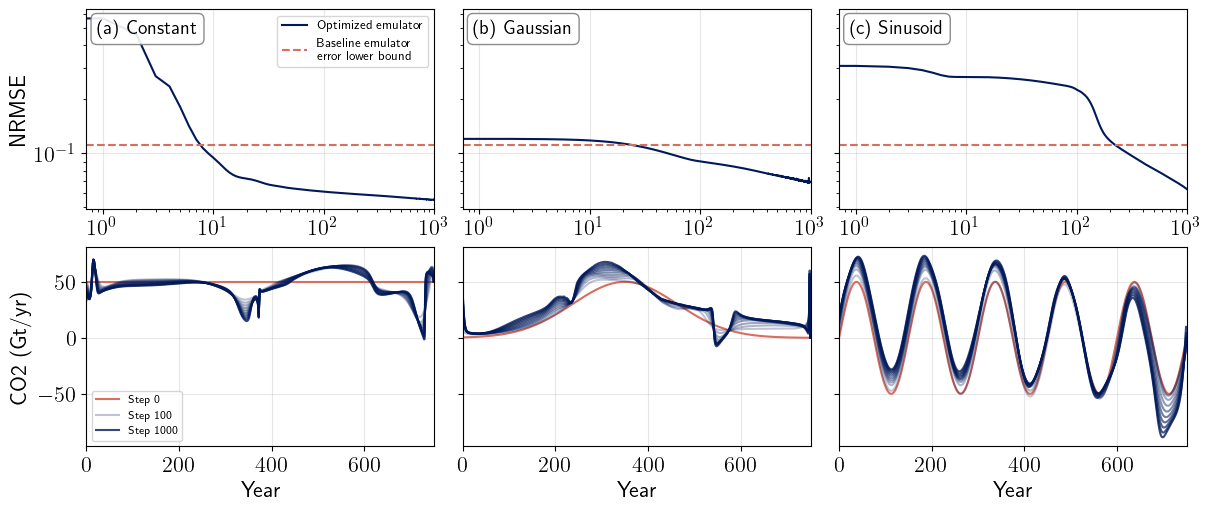

In [4]:
utils_plotting.plot_comparison_results(**fig_ic_data)

### MLP-architecture sensitivity (CO2-only: [8] / [16] / [32] / [16, 16])

In [5]:
fig_arch_data = utils_inverse.load_SI_architecture_sensitivity_data()

/Users/chriswomack/Documents/PhD/Project 2/utils_plotting.py:2620: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax_err.set_xlim(0, n_update_steps)


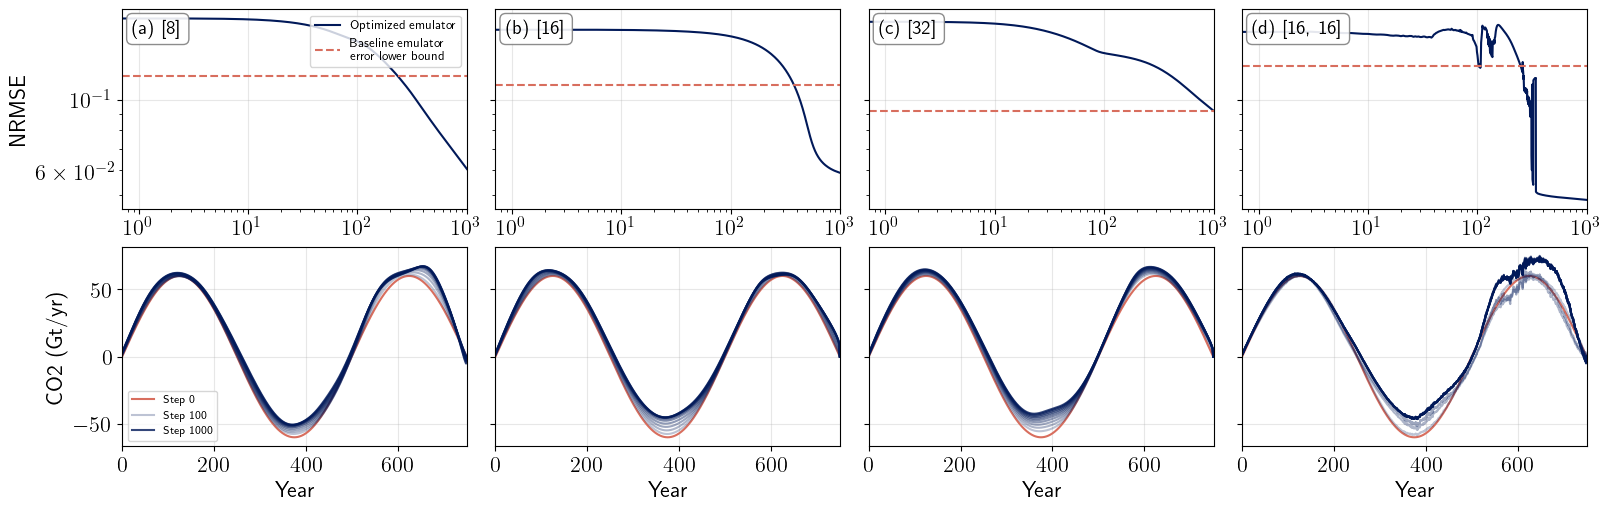

In [6]:
utils_plotting.plot_comparison_results(**fig_arch_data)

### Feature-window sensitivity (CO2-only: short / medium / long EMA horizons)

In [7]:
fig_feat_data = utils_inverse.load_SI_feature_sensitivity_data()

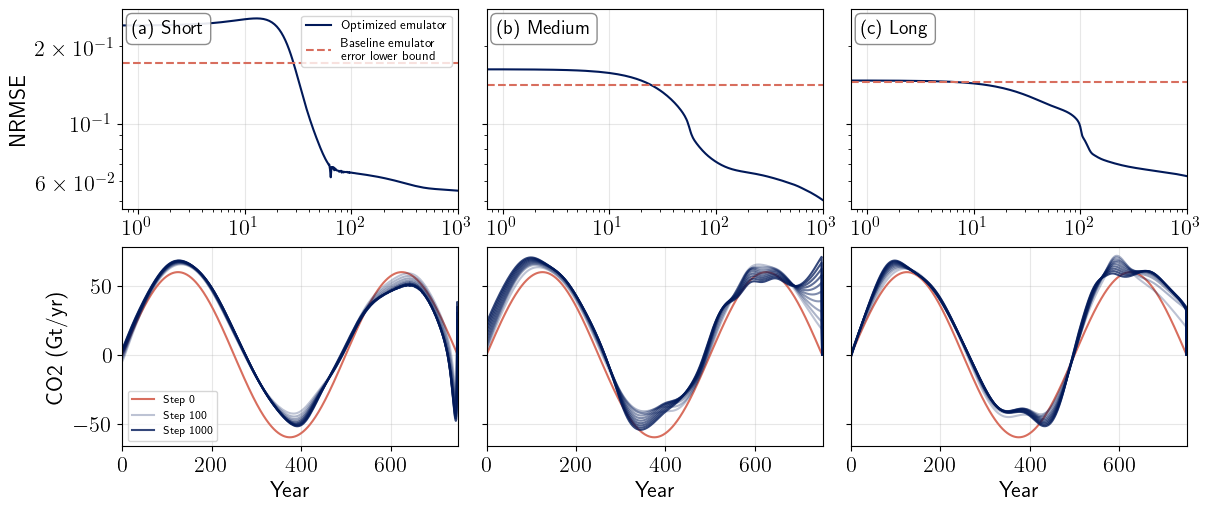

In [8]:
utils_plotting.plot_comparison_results(**fig_feat_data)

### Extended results: single-agent optimizations across CO2/CH4/N2O/Sulfur/BC

In [9]:
# N2O/Sulfur/BC entries refreshed via
# scripts/supplementary_notebooks/SI_plots.py (run standalone/scheduled);
# the CO2/CH4 entries come from a separate, untracked process (see
# utils_inverse.regenerate_SI_extended_results_cache's docstring).
fig_extended_data = utils_inverse.load_SI_extended_results_data()

In [10]:
# (Removed) This cell used to rename a stale 'Opt CS3' key to 'Opt. CS3' in
# the on-disk optimal_{agent}_only.pkl caches for ch4/n2o/Sulfur/BC - a
# one-time fix for an inconsistently-named key produced by an older version
# of the generation process. Confirmed via direct inspection that every
# cache currently on disk (including 'co2', which this cell never even
# covered) already has the corrected 'Opt. CS3' key, so re-running this
# rename today would KeyError on `res.pop('Opt CS3')`. Not migrated to
# scripts/supplementary_notebooks/SI_plots.py - flagged here rather than
# silently dropped, since it documents why the key is spelled 'Opt. CS3'.

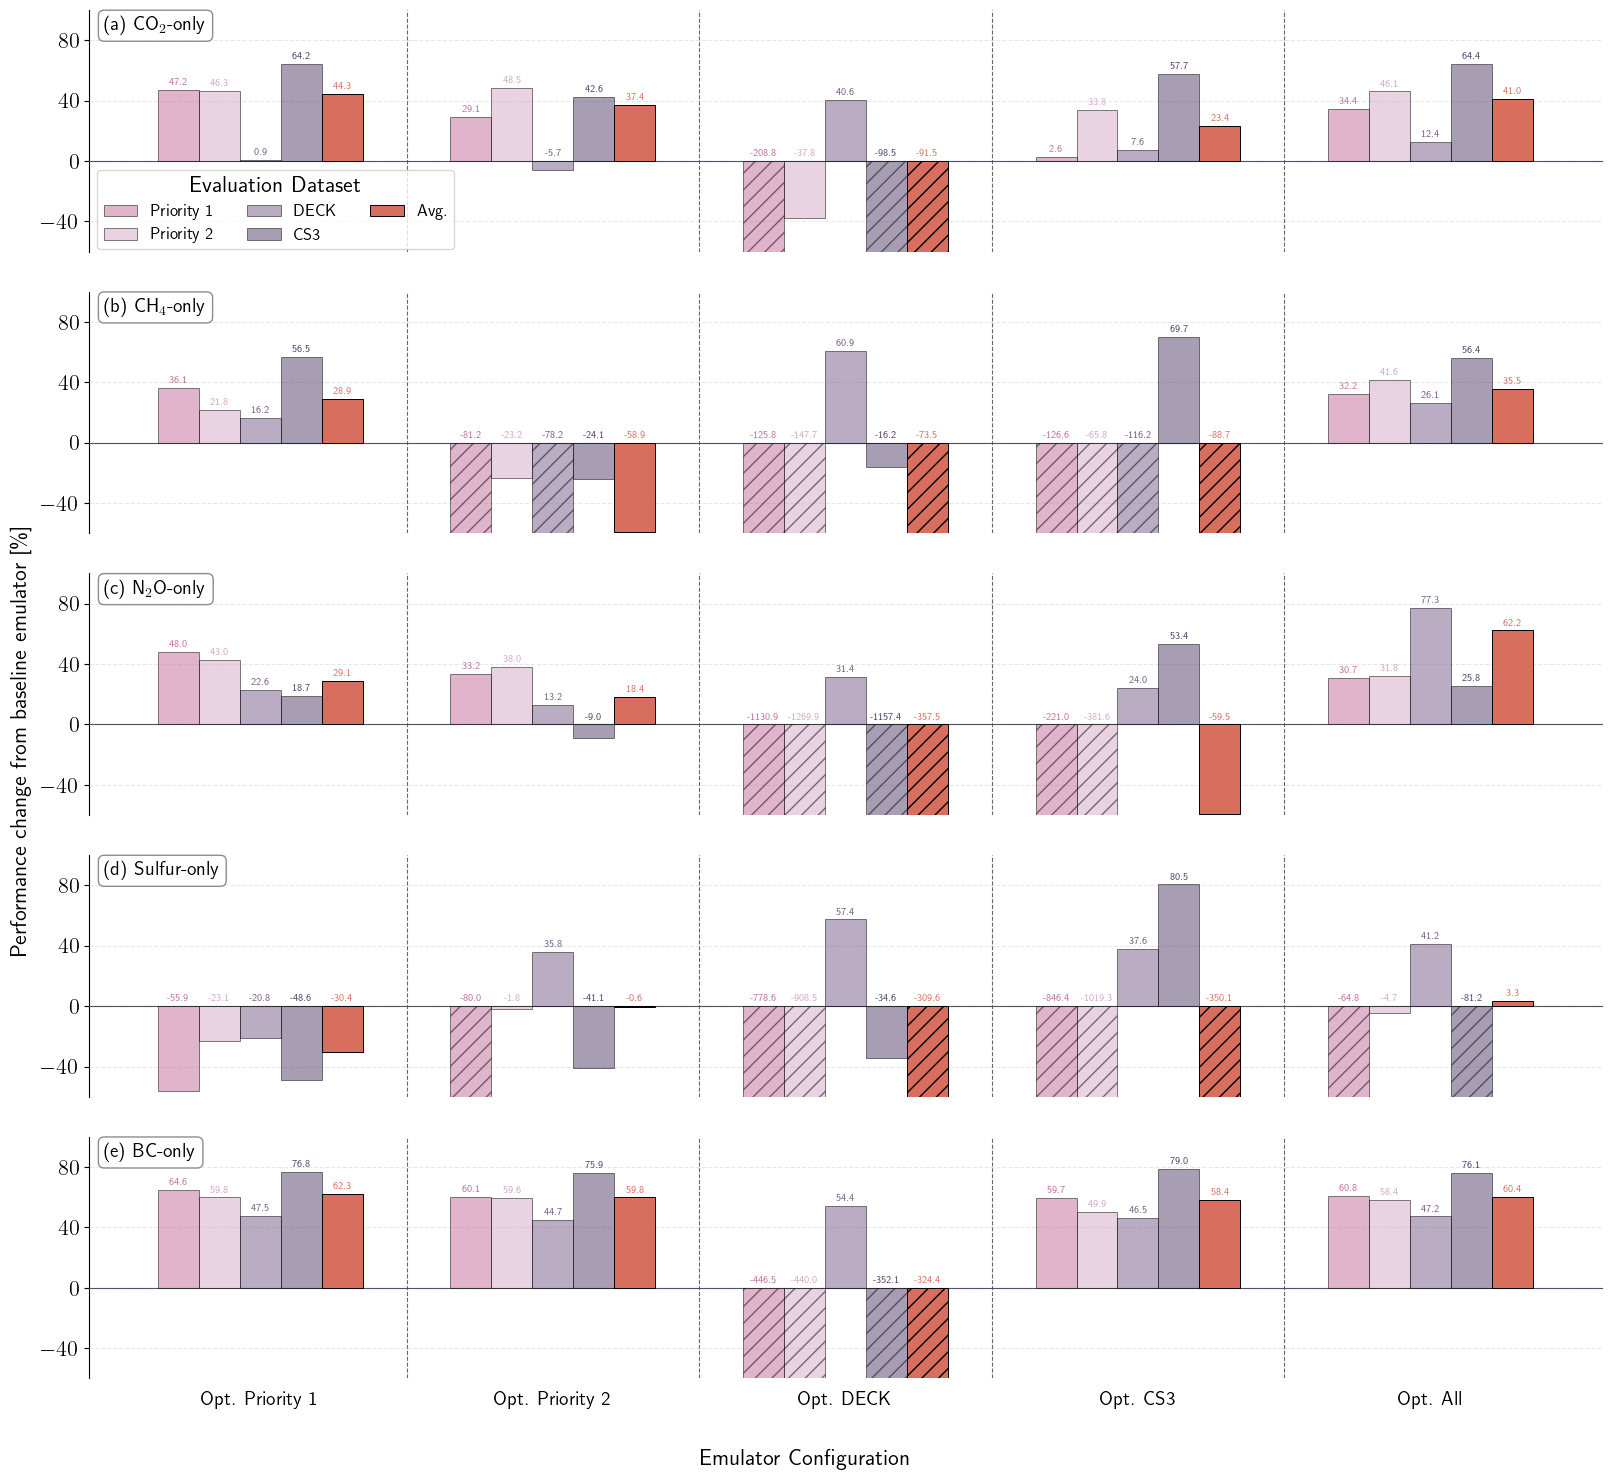

In [11]:
utils_plotting.plot_vertical_stacked_bars(**fig_extended_data)

### Extended results, seed spread (50 seeds - CO2/CH4/N2O/Sulfur/BC)

Multi-seed companion to the cell above: mean +/- std error bars across 50
seeds per agent, using each agent's own Stage 0b/0c retuned checkpoints
(`checkpoints/{agent}_retuned/seed_sweep/`). Requires
`regenerate_fig4_co2_only_cache_seed_sweep` (CO2) and
`regenerate_SI_extended_results_cache_seed_sweep` (CH4/N2O/Sulfur/BC) to
have been run first - raises `FileNotFoundError` naming the missing
agent/cache otherwise, rather than silently mixing seeded and
single-point panels.

In [12]:
fig_extended_seed_data = utils_inverse.load_SI_extended_results_data_seed_sweep()

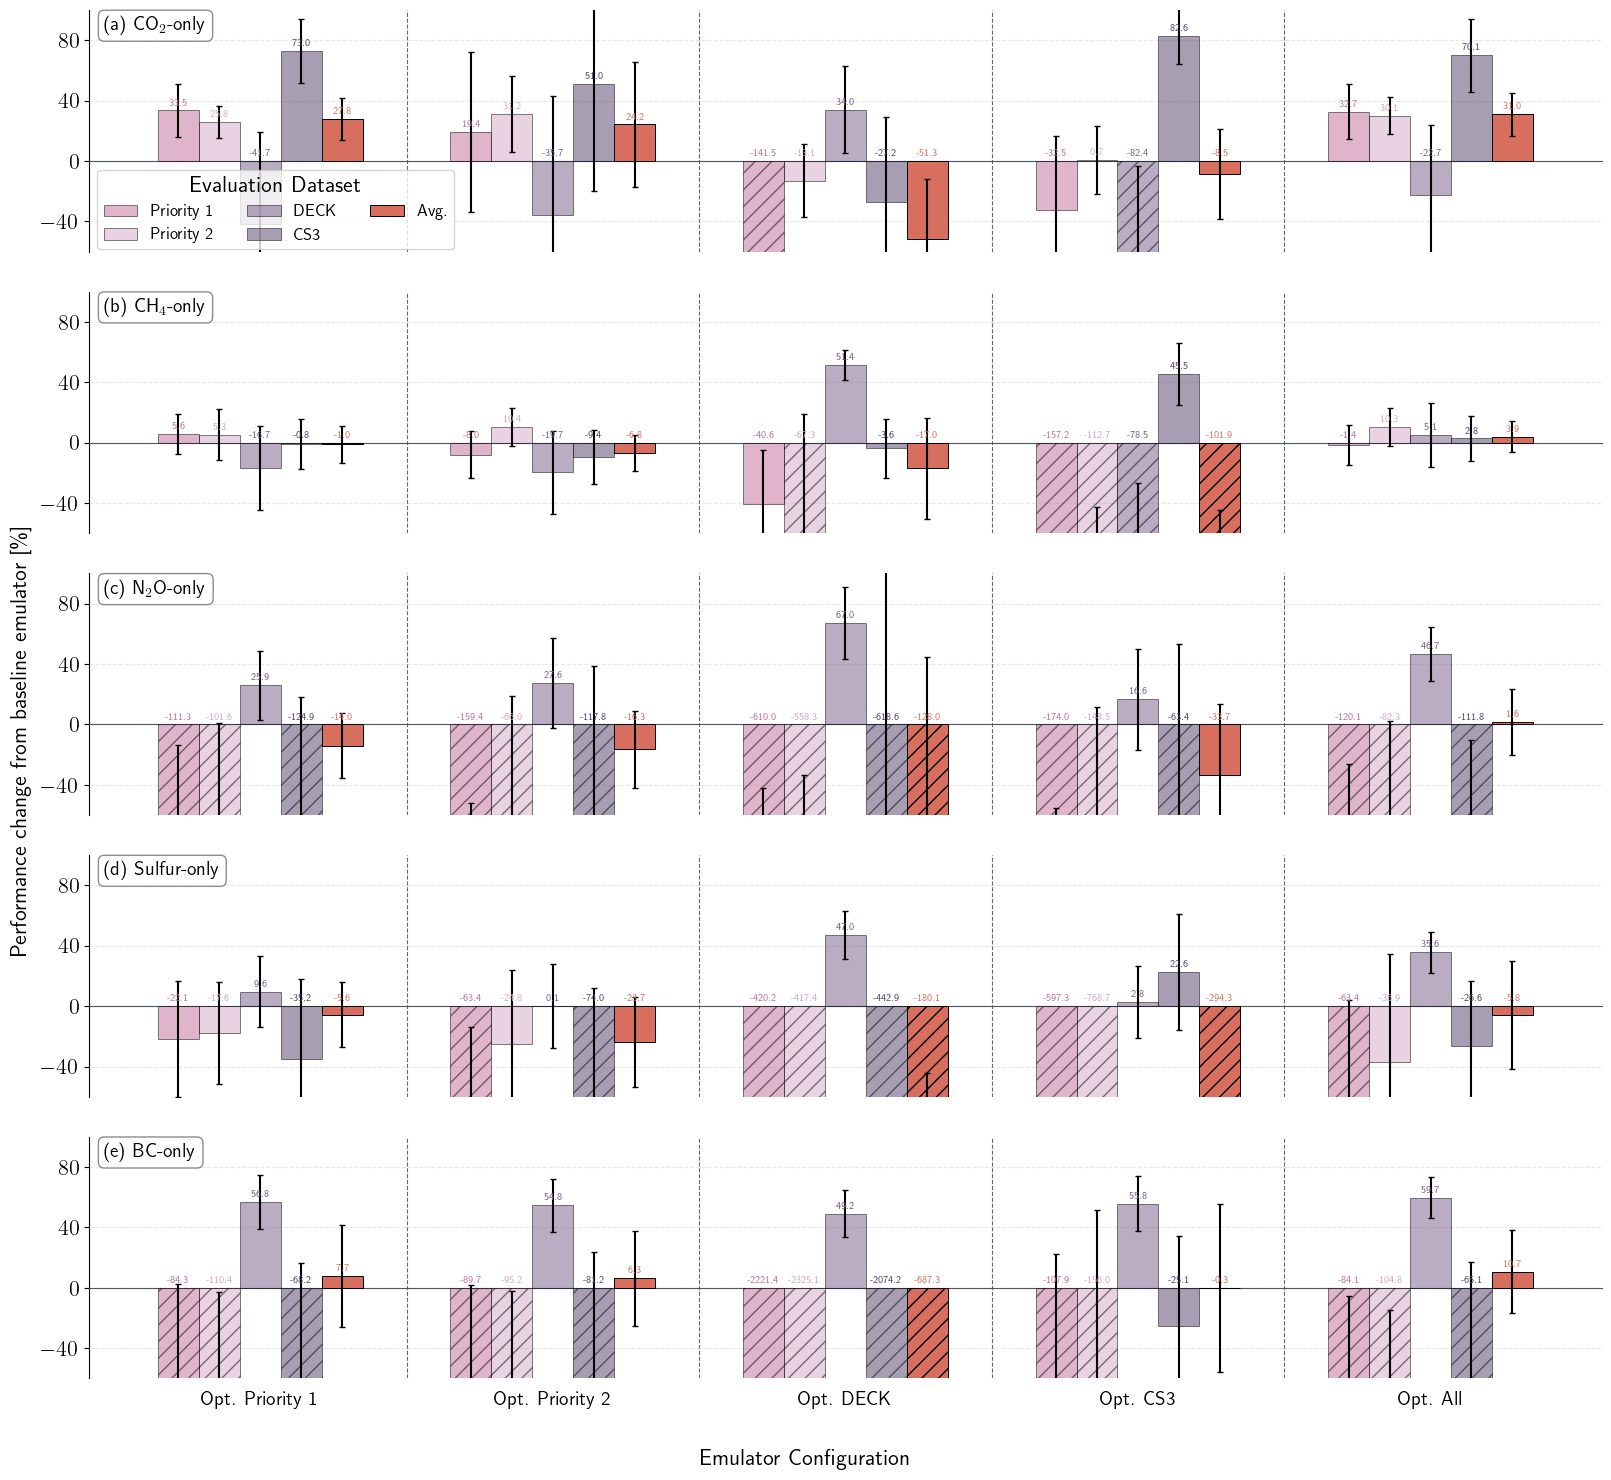

In [13]:
utils_plotting.plot_vertical_stacked_bars(**fig_extended_seed_data)